In [1]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np
from scipy.ndimage import label
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# pull sample data to work with
def fetch_image(url):
    # using different combination of header seems to help with the anti scrape problem
    headers_sample = [
    
    {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.5 Safari/605.1.15",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
    }
,
    {
    "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_4 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Mobile/15E148 Safari/604.1",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
    }
,
    {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:143.0) Gecko/20100101 Firefox/143.0",
    "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
    }
,
    {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.5 Safari/605.1.15",
    }
,
    {
    "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_4 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Mobile/15E148 Safari/604.1",
    }
,
    {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:143.0) Gecko/20100101 Firefox/143.0",
    }
]

    for header in headers_sample :
        r = requests.get(url, timeout=15,headers=header) # try each header 
        r.raise_for_status() # new line for downstream functionality 
        return r.content




https://www.nea.gov.sg/docs/default-source/rain-area/dpsri_70km_2025100910100000dBR.dpsri.png


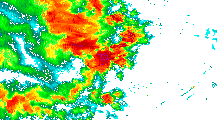

(217, 120)
<class 'PIL.PngImagePlugin.PngImageFile'>


In [3]:
ts_str = '202510091010'

url = 'https://www.nea.gov.sg/docs/default-source/rain-area/dpsri_70km_'+ts_str+'0000dBR.dpsri.png'
print(url)

# res = fetch_image(url)
# with open('sample_data/test_image.jpg','wb') as f:
#     f.write(res)

with open('sample_data/test_image.jpg','rb') as f:
    data = f.read()


image_buffer = BytesIO(data)

img = Image.open(image_buffer)
display(img)

print(img.size)
print(type(img))

In [ ]:
# helpers 
legend = [
    ((  0, 255, 255),  5.0),  # cyan
    ((  0, 200, 150), 10.0),  # aqua-green
    ((  0, 255,   0), 20.0),  # green
    ((150, 255,   0), 28.0),  # yellow-green
    ((255, 255,   0), 35.0),  # yellow
    ((255, 200,   0), 42.0),  # amber
    ((255, 150,   0), 50.0),  # orange
    ((255, 100,   0), 58.0),  # red-orange
    ((255,   0,   0), 65.0),  # red
    ((255,   0, 255), 70.0),  # magenta/purple
]

def rgb_to_dbz(img) :
    img_convert = img.convert('RGBA')
    rgba_array = np.array(img_convert,dtype= np.uint8)

    # decompose the channels
    rgb = rgba_array[... , :3] 
    alpha = rgba_array[... , 3]
    H, W = rgb.shape[:2]
    mask = alpha > 0 

    # legend arrays
    legend_rgb = np.array([c for c, _ in legend], dtype=np.int16)   # (K,3)
    legend_dbz = np.array([z for _, z in legend], dtype=np.float32) # (K,)

    # 3) flatten pixels for vectorized distance calc
    flat = rgb.reshape(-1, 3) # from grid to single list of each pixel
    N, K = flat.shape[0], legend_rgb.shape[0]

    # 4) l2 distances to all legend colors (N,K)
    d2 = np.sum((flat[:, None, :] - legend_rgb[None, :, :])**2, axis=2)  # squared distances
    d  = np.sqrt(d2, dtype=np.float32)

    # 5) find top 2 closest
    nearest_two = np.argsort(d, axis=1)[:, :2]   
    i0 = nearest_two[:, 0]                      
    i1 = nearest_two[:, 1]                      

    d0 = d[np.arange(N), i0]                     
    d1 = d[np.arange(N), i1]                     
    z0 = legend_dbz[i0]                            
    z1 = legend_dbz[i1]                             


    exact = (d0 == 0.0)
    # start with zeros
    dbz_flat = np.zeros(N, dtype=np.float32)

    eps = 1e-6
    w0 = np.where(exact, 1.0, 1.0 / np.maximum(d0, eps))
    w1 = np.where(exact, 0.0, 1.0 / np.maximum(d1, eps))
    num = w0 * z0 + w1 * z1
    den = w0 + w1
    dbz_flat = np.where(exact, z0, num / np.maximum(den, eps))

    dbz_grid = dbz_flat.reshape(H, W)
    dbz_grid[~mask] = float(0)

    return np.rint(dbz_grid).astype(int)

def binary_storm_mask(dbz_grid,threshold_dbz) : 
    mask = (dbz_grid >= threshold_dbz).astype(np.uint8)
    return mask

def filter_by_area(storm_mask
                   ,dbz_grid
                   ,min_area_px):
    
    # identifying connected components
    structure = np.ones((3, 3), dtype=int)
    labels_raw, n_raw = label(storm_mask.astype(np.uint8), structure=structure)

    # checking for each component
    keep = np.zeros_like(labels_raw, dtype=bool)
    for lab in range(1, n_raw + 1):
        comp = (labels_raw == lab) # masks only the current storm to 1, else is 0 
        area = int(comp.sum())
        if area < min_area_px: # must be big enoogh
            continue
        peak = float(dbz_grid[comp].max()) if area > 0 else -np.inf
        keep |= comp

    # relabelled only filtered 
    labels_kept, n_kept = label(keep.astype(np.uint8), structure=structure)

    # for each possible storm find area, peak, centriod (geometric center relative to storm) and anchor pixel closest pair to the storm centriod just round off
    records = []
    for new_id in range(1, n_kept + 1):
        comp = (labels_kept == new_id) # binary mask

        # area
        area_px = int(comp.sum()) # sum of array 

        # peak & anchor pixel 
        values = dbz_grid[comp] # pull reflectivity numbers for this storm
        peak_dbz = float(values.max()) if area_px > 0 else float("-inf") # find peak dbz in the storm, -inf is safety net 
        ys, xs = np.where(comp) # return every pixel coordinate in the storm
        # print(ys)
        # print(xs)
        
        # centroid (geometric center) — floats
        centroid_y = float(ys.mean()) if area_px > 0 else np.nan
        centroid_x = float(xs.mean()) if area_px > 0 else np.nan

        records.append({
            "new_id": new_id,
            "area_px": area_px,
            "peak_dbz": round(peak_dbz, 2),
            "anchor_y": round(centroid_y,0), # just round to near whole number, for down stream processing
            "anchor_x": round(centroid_x,0),
            "centroid_y": round(centroid_y, 2),
            "centroid_x": round(centroid_x, 2),
        })

    storm_df = pd.DataFrame.from_records(
        records,
        columns=["new_id", "area_px", "peak_dbz", "anchor_y", "anchor_x", "centroid_y", "centroid_x"]
    )

    return labels_kept, storm_df


In [37]:
def image_to_possible_storm(
    data
    ,dbz_threshold
    ,min_area_threshold
) : 
    
    image_buffer = BytesIO(data)
    img = Image.open(image_buffer)

    # convert from image bytedata -> RGB channel data -> map RGB values by distance to dBz 
    dbz_per_pixel = rgb_to_dbz(img)

    # filter on a fixed threshold 
    dbz_above_threshold = binary_storm_mask(dbz_per_pixel,dbz_threshold)

    # from binary storm mask , identify connected components and filter again on minimum storm area
    possible_storm_grid , possible_storm_df = filter_by_area(dbz_above_threshold,dbz_per_pixel,min_area_threshold)

    return possible_storm_grid, possible_storm_df

In [38]:
a,b = image_to_possible_storm(data,50,80)
b

/var/folders/c9/rl6pcdvd1_xb6ng3n8l9wr2w0000gn/T/ipykernel_57578/2052172951.py:48: RuntimeWarning: invalid value encountered in sqrt
  d  = np.sqrt(d2, dtype=np.float32)


,new_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x
0,1,2009,68.0,36.0,83.0,35.76,82.83
1,2,125,68.0,5.0,96.0,5.50,95.50
2,3,95,68.0,18.0,115.0,17.88,114.91
3,4,89,62.0,75.0,41.0,74.64,41.36
4,5,178,68.0,103.0,14.0,102.81,13.60


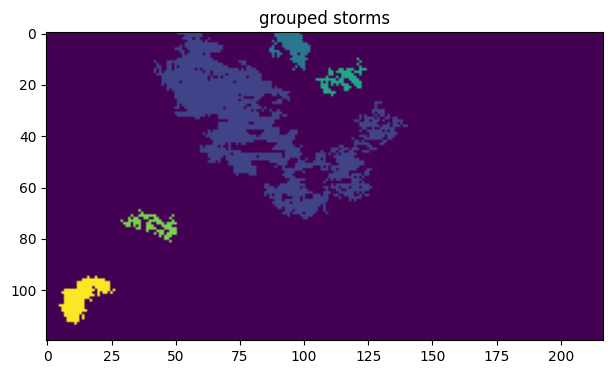

In [28]:
plt.figure(figsize=(8,4))           
plt.imshow(a)      
plt.title("grouped storms")
plt.show()